<a href="https://colab.research.google.com/github/roblero-gunn/Proyecto1_CoffeeLeafs/blob/main/dev_model/ResNet18_DataAugmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***ResNet18 con Data Augmentation***

# Paqueterías

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights
import shutil

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import copy
from tqdm import tqdm

import random

from torch.utils.data import Subset, DataLoader, WeightedRandomSampler
import torchvision.models as models

from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cpu
CUDA disponible: False


# Carga del Dataset

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
from google.colab import drive

# Esto montará tu Google Drive en la carpeta virtual de Colab
drive.mount('/content/drive')
print(" Google Drive conectado exitosamente.")

Mounted at /content/drive
 Google Drive conectado exitosamente.


In [ ]:
from google.colab import drive
# El force_remount=True obliga a Colab a reparar la conexión rota
drive.mount('/content/drive', force_remount=True)
print(" Conexión con Drive restablecida.")

Mounted at /content/drive
 Conexión con Drive restablecida.


In [ ]:
# Rutas
ruta_zip_drive = "/content/drive/MyDrive/Dataset_Maestro_RoCoLe.zip"
ruta_zip_local = "/content/Dataset_Maestro_RoCoLe.zip"
carpeta_destino = "/content/Dataset_Maestro_RoCoLe"

if os.path.exists(ruta_zip_drive):
    # Copiar el ZIP completo desde Drive a la memoria rápida (Evita el error 107)
    print(" 1/2: Copiando el archivo ZIP desde Drive a Colab (esto tomará unos segundos)...")
    shutil.copy2(ruta_zip_drive, ruta_zip_local)

    # Descomprimir el archivo que ya está 100% en la memoria local
    print(" 2/2: Descomprimiendo el archivo local...")
    shutil.unpack_archive(ruta_zip_local, carpeta_destino)

    print(f" ¡Éxito total! Tu dataset está listo en la carpeta '{carpeta_destino}'.")

    # Opcional: Borrar el ZIP local para liberar espacio en RAM
    os.remove(ruta_zip_local)
else:
    print(f"  Error: No se encontró el ZIP en Drive. Asegúrate de que siga ahí.")

 1/2: Copiando el archivo ZIP desde Drive a Colab (esto tomará unos segundos)...
 2/2: Descomprimiendo el archivo local...
 ¡Éxito total! Tu dataset está listo en la carpeta '/content/Dataset_Maestro_RoCoLe'.


# Transformación de Datos

In [ ]:
#  Definimos las transformaciones de ENTRENAMIENTO (Con Data Augmentation seguro)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Redimensionar sin recortar (para no perder síntomas en los bordes)
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Definimos las transformaciones de VALIDACIÓN/TEST (Limpias, sin cambios aleatorios)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# INSTANCIAR EL DATASET usando la herramienta estándar de PyTorch
# Usamos la ruta donde descomprimiste tu ZIP
ruta_datos = '/content/Dataset_Maestro_RoCoLe'

# Creamos dos versiones: una para estudiar (con aumentos) y otra para evaluar (limpia)
train_base = datasets.ImageFolder(root=ruta_datos, transform=train_transforms)
val_base = datasets.ImageFolder(root=ruta_datos, transform=val_transforms)

# 4. DIVISIÓN 70% / 20% / 10%
num_imagenes = len(train_base)
indices = torch.randperm(num_imagenes, generator=torch.Generator().manual_seed(42)).tolist()

train_size = int(0.70 * num_imagenes)
test_size = int(0.20 * num_imagenes)
val_size = num_imagenes - train_size - test_size

train_idx = indices[:train_size]
test_idx = indices[train_size : train_size + test_size]
val_idx = indices[train_size + test_size:]

# Creamos los subsets formales
train_dataset = Subset(train_base, train_idx)
test_dataset = Subset(val_base, test_idx)
val_dataset = Subset(val_base, val_idx)

print(f" Dataset cargado y dividido:")
print(f"   - Entrenamiento: {len(train_dataset)}")
print(f"   - Prueba (Test): {len(test_dataset)}")
print(f"   - Validación:   {len(val_dataset)}")

 Dataset cargado y dividido:
   - Entrenamiento: 1158
   - Prueba (Test): 331
   - Validación:   166


# Cargar dataset y dividir en train/val/test con balance de clases

In [ ]:
#  Extraer las etiquetas SOLO del conjunto de entrenamiento
# (Accedemos al dataset base y sacamos la etiqueta usando los índices del subset)
etiquetas_train = [train_dataset.dataset.targets[i] for i in train_dataset.indices]

# 2. Contar cuántas imágenes quedaron de cada clase
conteo_clases = np.bincount(etiquetas_train)
print(f" Distribución real en Entrenamiento: {conteo_clases}")

# 3. Calcular los pesos matemáticos
# Las clases con menos fotos tendrán un peso mucho mayor
pesos_clases = 1.0 / conteo_clases
pesos_muestras = [pesos_clases[etiqueta] for etiqueta in etiquetas_train]

# 4. Crear el Sampler
# Le pedimos 8000 extracciones permitiendo repetición (replacement=True)
sampler_balanceado = WeightedRandomSampler(
    weights=pesos_muestras,
    num_samples=8000,
    replacement=True
)

# 5. Crear los DataLoaders (Los trabajadores que llevan los datos a la GPU)
batch_size = 32 # Lotes de 32 imágenes a la vez

# OJO: Train usa el sampler. Val y Test NO, porque son exámenes normales.
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler_balanceado)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\n ¡DataLoaders creados con éxito!")
print(f"El train_loader entregará {len(train_loader)} lotes de {batch_size} imágenes por época.")

 Distribución real en Entrenamiento: [369 336 344 109]

 ¡DataLoaders creados con éxito!
El train_loader entregará 250 lotes de 32 imágenes por época.


 Muestra de cómo el modelo está viendo los datos (con Data Augmentation):


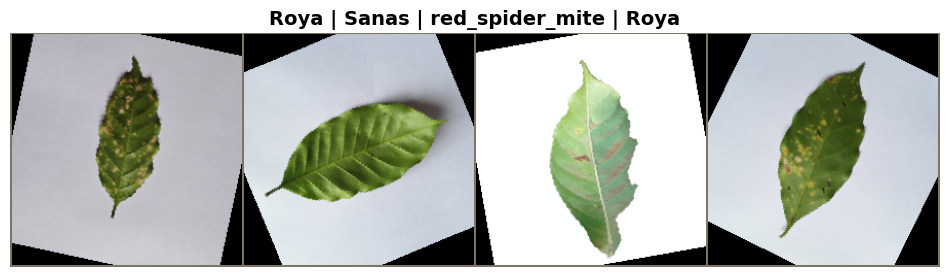

In [ ]:
# 1. Obtener un lote (batch) de imágenes y etiquetas de tu DataLoader ya balanceado
imagenes, etiquetas = next(iter(train_loader))

# 2. Tomar solo las primeras 4 imágenes para no saturar la pantalla
imagenes = imagenes[:4]
etiquetas = etiquetas[:4]

# 3. Función para deshacer la normalización matemática y poder ver los colores reales
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)

    plt.figure(figsize=(12, 5))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# 4. Crear una cuadrícula visual con las imágenes
out = torchvision.utils.make_grid(imagenes)

# 5. Construir el título dinámico consultando la variable correcta (train_base)
nombres_etiquetas = [train_base.classes[e.item()] for e in etiquetas]
titulo_dinamico = " | ".join(nombres_etiquetas)

# 6. Mostrar el resultado
print(" Muestra de cómo el modelo está viendo los datos (con Data Augmentation):")
imshow(out, title=titulo_dinamico)

# Cargar Resnet18

In [ ]:
#Cargar ResNet18 preentrenado
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

print("Modelo ResNet18 cargado con pesos de ImageNet")
print(f"\nArquitectura original de la última capa:")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 345MB/s]

Modelo ResNet18 cargado con pesos de ImageNet

Arquitectura original de la última capa:
Linear(in_features=512, out_features=1000, bias=True)


In [ ]:
# PASO CLAVE: Congelar todas las capas del modelo
print("\n=== CONGELANDO CAPAS ===")
for param in model.parameters():
    param.requires_grad = False

print("[+] Todas las capas congeladas (requires_grad = False)")

# Verificar que las capas estén congeladas
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"  Parámetros congelados: {frozen_params:,}")


=== CONGELANDO CAPAS ===
[+] Todas las capas congeladas (requires_grad = False)
  Parámetros congelados: 11,689,512


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

'''
 EL PASO CLAVE: Congelar las capas previas
'''

for param in model.parameters():
    param.requires_grad = False

# Definir número de clases usando train_base
num_classes = len(train_base.classes)

# Extraer el número de características de entrada
num_ftrs = model.fc.in_features

# Reemplazar la capa final. Esta nueva capa SÍ tendrá requires_grad=True automáticamente
model.fc = nn.Linear(num_ftrs, num_classes)

print(f"\n=== NUEVA CAPA FINAL PARA RoCoLe ===")
print(f"Adaptando de 1000 clases (ImageNet) a {num_classes} clases (RoCoLe)")
print(f"Arquitectura de la nueva capa: {num_ftrs} entradas -> {num_classes} salidas")
print(model.fc)

# Mover a la GPU
model = model.to(device)

# Calcular los parámetros
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"\n=== RESUMEN DE PARÁMETROS ===")
print(f"Total de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Parámetros congelados: {total_params - trainable_params:,}")
print(f"Porcentaje entrenable: {100 * trainable_params / total_params:.2f}%")


=== NUEVA CAPA FINAL PARA RoCoLe ===
Adaptando de 1000 clases (ImageNet) a 4 clases (RoCoLe)
Arquitectura de la nueva capa: 512 entradas -> 4 salidas
Linear(in_features=512, out_features=4, bias=True)

=== RESUMEN DE PARÁMETROS ===
Total de parámetros: 11,178,564
Parámetros entrenables: 2,052
Parámetros congelados: 11,176,512
Porcentaje entrenable: 0.02%


# Función de entrenamiento

In [ ]:

def train_model(model, criterion, optimizer, scheduler, num_epochs=20):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'\nÉpoca {epoch+1}/{num_epochs}')
        print('-' * 60)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f'{phase.capitalize()}')
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            if phase == 'train' and scheduler is not None:
                scheduler.step()

            # ¡AQUÍ ESTÁ LA MAGIA DEL CÁLCULO CORRECTO!
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Guardar el modelo en RAM y EN TU DRIVE
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # ¡Guardado seguro en Drive!
                torch.save(model.state_dict(), ruta_guardado)
                print(f' Mejor modelo guardado en Drive (Acc: {best_acc:.4f})')

    time_elapsed = time.time() - since
    print(f'\n{"="*60}')
    print(f'Entrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor accuracy de validación: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

'''
 PREPARATIVOS FINALES Y EJECUCIÓN
'''

# Definir Ruta, Pérdida y Optimizador
ruta_guardado = '/content/drive/MyDrive/resnet18_rocole_mejor_modelo.pth'
criterion = nn.CrossEntropyLoss()
# Le pasamos al optimizador SOLO los parámetros que no están congelados (la última capa)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Empaquetamos los loaders y tamaños para que la función los entienda
dataloaders = {
    'train': train_loader,
    'val': val_loader
}

dataset_sizes = {
    'train': 8000, # Nuestro Sampler obliga a extraer 8000
    'val': len(val_dataset) # Validación usa su tamaño normal
}

# Creamos un Scheduler (Reduce el Learning Rate a la mitad cada 7 épocas para afinar detalles)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

# Entrenamiento
print(" Iniciando el motor de entrenamiento...")
modelo_entrenado, historial = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=exp_lr_scheduler,
    num_epochs=10
)

 Iniciando el motor de entrenamiento...

Época 1/10
------------------------------------------------------------


Train: 100%|██████████| 250/250 [10:04<00:00,  2.42s/it, loss=0.1982]


Train Loss: 0.4081 Acc: 0.8854


Val: 100%|██████████| 6/6 [00:14<00:00,  2.48s/it, loss=0.1589]


Val Loss: 0.2777 Acc: 0.9096
 Mejor modelo guardado en Drive (Acc: 0.9096)

Época 2/10
------------------------------------------------------------


...

Val Loss: 0.0869 Acc: 0.9699

Época 10/10
------------------------------------------------------------


Train: 100%|██████████| 250/250 [10:11<00:00,  2.44s/it, loss=0.0634]


Train Loss: 0.0708 Acc: 0.9771


Val: 100%|██████████| 6/6 [00:14<00:00,  2.36s/it, loss=0.0146]

Val Loss: 0.0881 Acc: 0.9699

Entrenamiento completado en 101m 5s
Mejor accuracy de validación: 0.9759


# Visualización resultados del entrenamiento

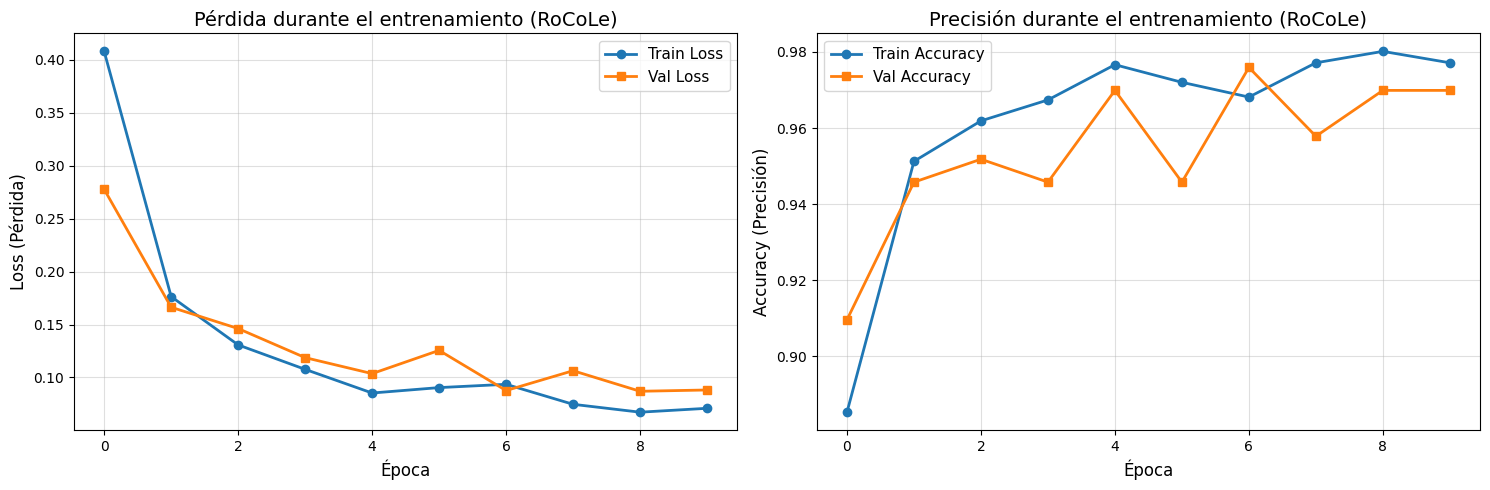


 RESULTADOS FINALES DEL ENTRENAMIENTO:
  Última Train Loss: 0.0708
  Última Train Acc:  0.9771
  Última Val Loss:   0.0881
  Última Val Acc:    0.9699
------------------------------------------------------------
 MEJOR VAL ACCURACY ALCANZADO: 0.9759


In [ ]:
# Crear una figura con dos subgráficos uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Pérdida (Loss)
axes[0].plot(historial['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(historial['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss (Pérdida)', fontsize=12)
axes[0].set_title('Pérdida durante el entrenamiento (RoCoLe)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

# Gráfico 2: Precisión (Accuracy)
axes[1].plot(historial['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(historial['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Accuracy (Precisión)', fontsize=12)
axes[1].set_title('Precisión durante el entrenamiento (RoCoLe)', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4)

# Ajustar los espacios y mostrar
plt.tight_layout()
plt.show()

# Imprimir resumen numérico
print(f"\n{'='*60}")
print(" RESULTADOS FINALES DEL ENTRENAMIENTO:")
print(f"{'='*60}")
print(f"  Última Train Loss: {historial['train_loss'][-1]:.4f}")
print(f"  Última Train Acc:  {historial['train_acc'][-1]:.4f}")
print(f"  Última Val Loss:   {historial['val_loss'][-1]:.4f}")
print(f"  Última Val Acc:    {historial['val_acc'][-1]:.4f}")
print("-" * 60)
print(f" MEJOR VAL ACCURACY ALCANZADO: {max(historial['val_acc']):.4f}")

# Guardar el modelo

In [ ]:
# Definir la ruta de guardado (puedes cambiar el nombre para guardar versiones)
# Ejemplo: 'modelo_rocole_final_v1.pth'
ruta_drive = '/content/drive/MyDrive/resnet18_rocole_final.pth'

# Guardar los "pesos" del modelo (state_dict)
# Esta es la forma recomendada por PyTorch
try:
    torch.save(modelo_entrenado.state_dict(), ruta_drive)
    print(f" ¡Éxito! El modelo se ha guardado en: {ruta_drive}")
except Exception as e:
    print(f" Error al guardar: {e}")
    print("Asegúrate de que Google Drive esté montado correctamente.")

#  *Opcional* Guardar el modelo completo (incluyendo la estructura)
# Esto ocupa más espacio pero es útil si cambias de notebook
    torch.save(modelo_entrenado, '/content/drive/MyDrive/resnet18_rocole_COMPLETO.pth')

 ¡Éxito! El modelo se ha guardado en: /content/drive/MyDrive/resnet18_rocole_final.pth


# Evaluación del test

In [ ]:
def evaluate_model(model, dataloader):
    """Evalúa el modelo en un dataloader y devuelve las predicciones y etiquetas reales."""
    model.eval()  # Fundamental: apaga Dropout y estabiliza BatchNorm
    all_preds = []
    all_labels = []

    # torch.no_grad() apaga el cálculo de gradientes para ahorrar muchísima memoria RAM y CPU/GPU
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluando Test'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1) # Extrae la clase con mayor probabilidad

            # Movemos los resultados de la GPU de vuelta a la CPU y los convertimos a NumPy
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

print("\n" + "="*60)
print(" EVALUACIÓN FINAL EN CONJUNTO DE TEST (20%)")
print("="*60)
print("Este conjunto es completamente nuevo para el modelo.\n")

# Evaluar exclusivamente en el DataLoader de Test usando nuestro modelo final
y_true, y_pred = evaluate_model(modelo_entrenado, test_loader)

# Calcular métricas generales (usamos 'weighted' por si hay clases con más imágenes que otras)
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"{'='*60}")
print(" MÉTRICAS GLOBALES EN TEST:")
print(f"{'='*60}")
print(f"  Accuracy (Exactitud): {test_accuracy:.4f}")
print(f"  Precision:            {test_precision:.4f}")
print(f"  Recall (Sensibilidad):{test_recall:.4f}")
print(f"  F1-Score:             {test_f1:.4f}")

# Reporte detallado desglosado por enfermedad/clase
print("\n" + "="*60)
print(" REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE")
print("="*60)
print(classification_report(
    y_true,
    y_pred,
    target_names=train_base.classes, # AQUÍ USAMOS NUESTRA VARIABLE ACTUALIZADA
    zero_division=0
))


 EVALUACIÓN FINAL EN CONJUNTO DE TEST (20%)
Este conjunto es completamente nuevo para el modelo.



Evaluando Test: 100%|██████████| 11/11 [00:25<00:00,  2.34s/it]

 MÉTRICAS GLOBALES EN TEST:
  Accuracy (Exactitud): 0.9698
  Precision:            0.9703
  Recall (Sensibilidad):0.9698
  F1-Score:             0.9698

 REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE
                 precision    recall  f1-score   support

      Ojo_Gallo       0.95      1.00      0.97        78
           Roya       0.96      0.96      0.96       116
          Sanas       0.99      0.95      0.97       107
red_spider_mite       1.00      1.00      1.00        30

       accuracy                           0.97       331
      macro avg       0.97      0.98      0.98       331
   weighted avg       0.97      0.97      0.97       331



# Matriz de confusión

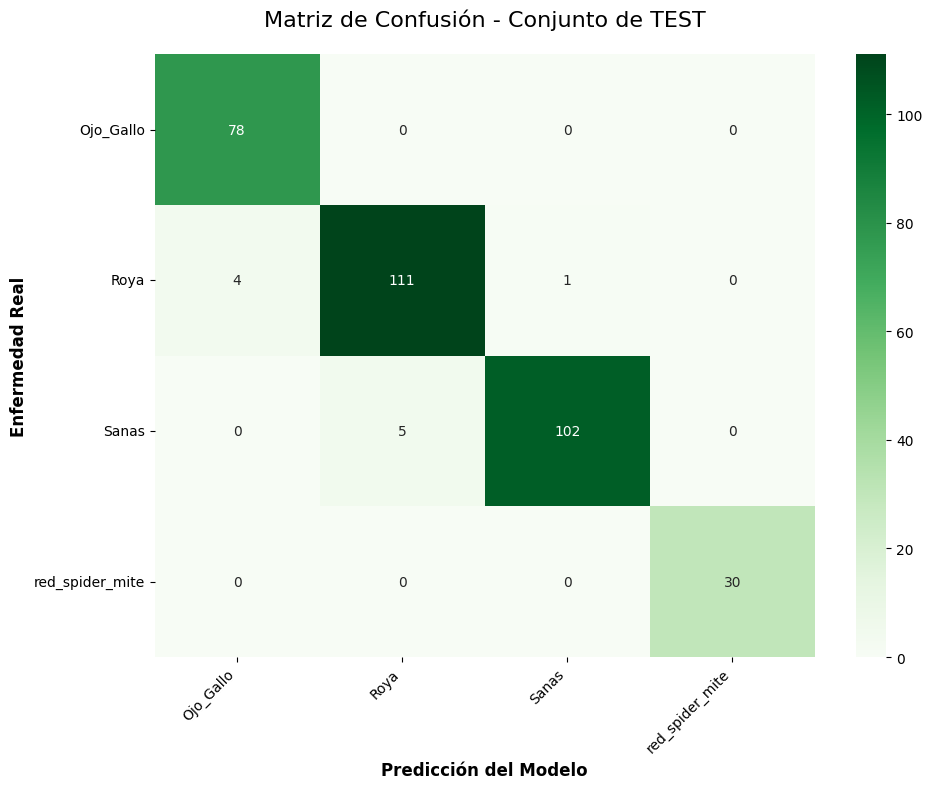


 ACCURACY POR ENFERMEDAD (CONJUNTO DE TEST):
Ojo_Gallo                : 1.0000 (78 hojas)
Roya                     : 0.9569 (116 hojas)
Sanas                    : 0.9533 (107 hojas)
red_spider_mite          : 1.0000 (30 hojas)

 VISUALIZACIÓN DE PREDICCIONES EN TEST


In [ ]:
# Calcular la matriz de confusión matemáticamente
cm = confusion_matrix(y_true, y_pred)

# Configurar el lienzo
plt.figure(figsize=(10, 8))

# Dibujar el mapa de calor (Heatmap)
sns.heatmap(
    cm,
    annot=True,     # Activado para ver los números exactos
    fmt='d',        # Muestra números enteros
    cmap='Greens',
    xticklabels=train_base.classes, # <--- Actualizado
    yticklabels=train_base.classes  # <--- Actualizado
)

# Etiquetas y diseño
plt.title('Matriz de Confusión - Conjunto de TEST', fontsize=16, pad=20)
plt.ylabel('Enfermedad Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Calcular Accuracy desglosado por cada clase
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\n" + "="*60)
print(" ACCURACY POR ENFERMEDAD (CONJUNTO DE TEST):")
print("="*60)
for i, acc in enumerate(class_accuracy):
    if not np.isnan(acc):
        count = cm.sum(axis=1)[i]
        print(f"{train_base.classes[i]:25s}: {acc:.4f} ({int(count)} hojas)") # <--- Actualizado

print("\n" + "="*60)
print(" VISUALIZACIÓN DE PREDICCIONES EN TEST")
print("="*60)

# Predicción


 VISUALIZANDO 8 PREDICCIONES AL AZAR (TEST)


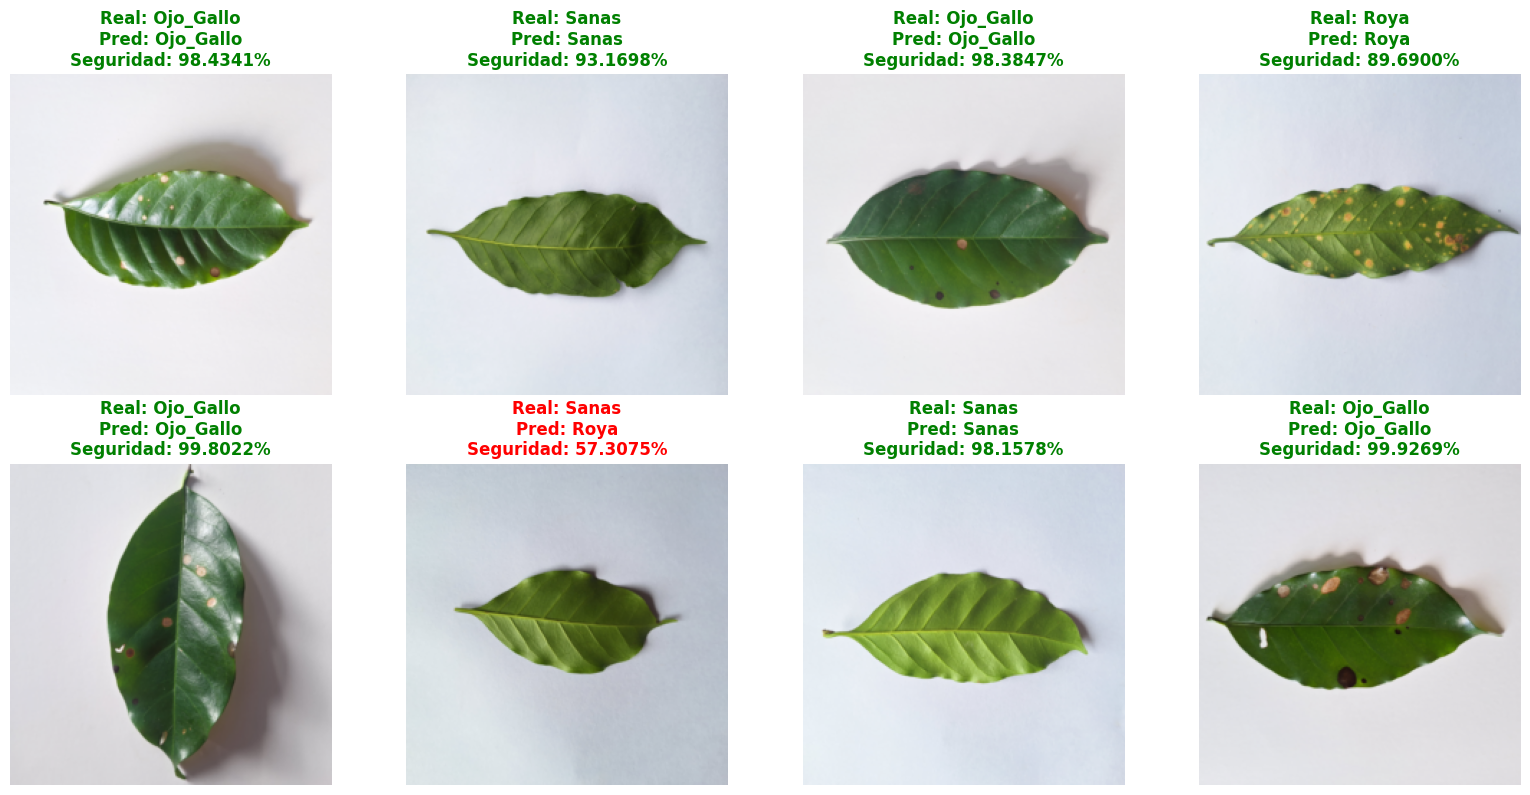

In [ ]:
def visualize_random_predictions(model, dataloader, nombres_clases, num_images=8):
    """
    Toma imágenes al azar del dataset, las pasa por el modelo
    y muestra visualmente si acertó o falló.
    """
    model.eval() # Modo evaluación (bloquea el aprendizaje)

    # Obtener el dataset completo que está "dentro" del dataloader
    dataset = dataloader.dataset

    # Elegir índices al azar (ej. si tienes 100 imágenes, elige 8 números al azar)
    indices_aleatorios = random.sample(range(len(dataset)), num_images)

    # Crear un lienzo para 8 imágenes (2 filas x 4 columnas)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    with torch.no_grad():
        for i, idx in enumerate(indices_aleatorios):
            # Extraer una sola imagen y su etiqueta real usando el índice al azar
            img_tensor, label_idx = dataset[idx]

            # PyTorch espera lotes (batches) [batch_size, canales, alto, ancho]
            # Usamos unsqueeze(0) para simular que le mandamos un lote de 1 sola imagen
            input_batch = img_tensor.unsqueeze(0).to(device)

            # Pasar la imagen por el modelo
            output = model(input_batch)

            # Calcular porcentajes
            probabilities = torch.nn.functional.softmax(output, dim=1)
            confidence, prediction = torch.max(probabilities, 1)

            # Desnormalizar la imagen para que se vea con sus colores reales
            img = img_tensor.cpu().numpy().transpose((1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            # Dibujar la imagen
            axes[i].imshow(img)
            axes[i].axis('off')

            # Preparar los textos
            true_label = nombres_clases[label_idx]
            pred_label = nombres_clases[prediction.item()]
            conf_pct = confidence.item() * 100

            # Color verde si acertó, rojo si falló
            color = 'green' if prediction.item() == label_idx else 'red'
            title = f'Real: {true_label}\nPred: {pred_label}\nSeguridad: {conf_pct:.4f}%'

            axes[i].set_title(title, fontsize=12, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

'''
EJECUTAMOS LA FUNCIÓN CON NUESTRO MODELO
'''
print("\n" + "="*60)
print(" VISUALIZANDO 8 PREDICCIONES AL AZAR (TEST)")
print("="*60)

visualize_random_predictions(
    model=modelo_entrenado,
    dataloader=test_loader,
    nombres_clases=train_base.classes,
    num_images=8
)